<a href="https://colab.research.google.com/github/muktiranisutradhar1-debug/special-parakeet/blob/main/Weather_forecasting_AUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install Libraries

In [68]:
!pip install xgboost

#Import Libraries

In [69]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

#Load Dataset

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ADMML PROJECT/weatherAUS.csv')

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [72]:
#Count Values
rain_today_counts = df['RainToday'].value_counts()
print(rain_today_counts)

rain_tomorrow_counts = df['RainTomorrow'].value_counts()
print(rain_tomorrow_counts)

RainToday
No     110319
Yes     31880
Name: count, dtype: int64
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


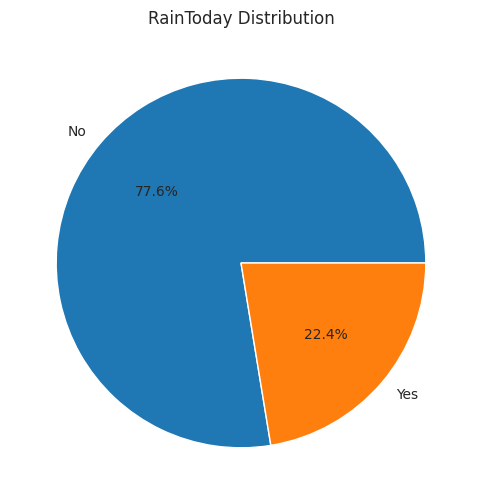

In [73]:
#Draw PIE Chart for RainToday
import matplotlib.pyplot as plt

rain_today_counts = df['RainToday'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    rain_today_counts,
    labels=rain_today_counts.index,
    autopct='%1.1f%%'
)

plt.title('RainToday Distribution')
plt.show()

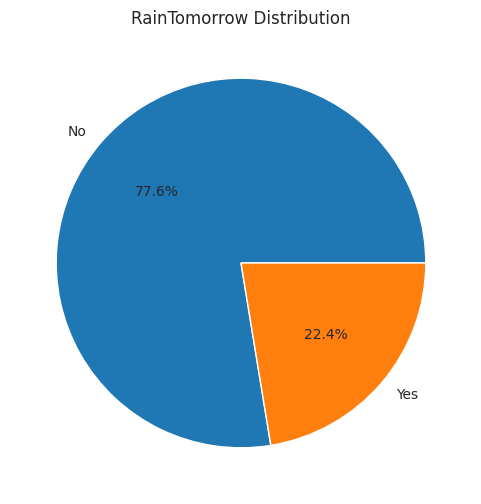

In [74]:
#FOR RAIN TOMORROW
rain_tomorrow_counts = df['RainTomorrow'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    rain_tomorrow_counts,
    labels=rain_tomorrow_counts.index,
    autopct='%1.1f%%'
)

plt.title('RainTomorrow Distribution')
plt.show()

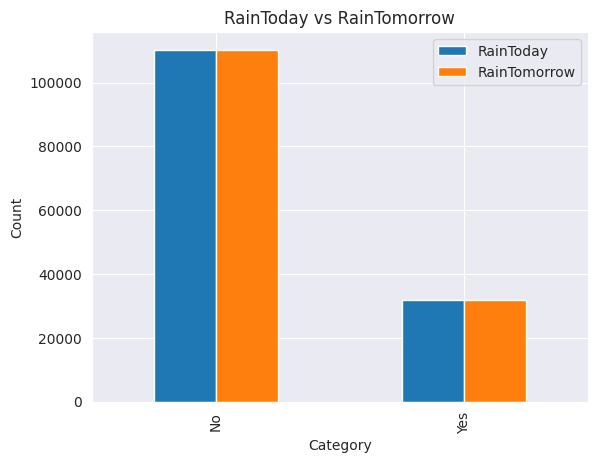

In [75]:
rain_today = df['RainToday'].value_counts()
rain_tomorrow = df['RainTomorrow'].value_counts()

comparison = pd.DataFrame({
    'RainToday': rain_today,
    'RainTomorrow': rain_tomorrow
})

comparison.plot(kind='bar')

plt.title('RainToday vs RainTomorrow')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend()
plt.show()

#Data Overview

In [76]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(145460, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       8

#Handle Missing Values

In [77]:
num_cols = df.select_dtypes(include=['float64','int64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

#Encode Categorical Variables

In [78]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [79]:
print(df.head())

   Date  Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0   396         2     13.4     22.9       0.6          4.8       8.4   
1   397         2      7.4     25.1       0.0          4.8       8.4   
2   398         2     12.9     25.7       0.0          4.8       8.4   
3   399         2      9.2     28.0       0.0          4.8       8.4   
4   400         2     17.5     32.3       1.0          4.8       8.4   

   WindGustDir  WindGustSpeed  WindDir9am  ...  Humidity9am  Humidity3pm  \
0           13           44.0          13  ...         71.0         22.0   
1           14           44.0           6  ...         44.0         25.0   
2           15           46.0          13  ...         38.0         30.0   
3            4           24.0           9  ...         45.0         16.0   
4           13           41.0           1  ...         82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7       1007.1   

#Features and Target

In [125]:
X = df.drop('RainTomorrow', axis=1)

y = df['RainTomorrow']

#Train, Validation, Test Split

In [128]:
from sklearn.model_selection import train_test_split

X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(x_train.shape)
print(y_train.shape)

(116368, 22)
(116368,)


#Random Forest Model

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,   # reduce from large values
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=42)

#Evaluation

In [101]:
#classification report and accuracy


# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Accuracy
print("Training Accuracy =", accuracy_score(y_train, y_train_pred) * 100)
print("Testing Accuracy =", accuracy_score(y_test, y_test_pred) * 100)

# Classification Report (Training)
print("\n--- Training Classification Report ---")
print(classification_report(y_train, y_train_pred))

# Classification Report (Testing)
print("\n--- Testing Classification Report ---")
print(classification_report(y_test, y_test_pred))

Training Accuracy = 88.2500834790124
Testing Accuracy = 85.10930840093496

--- Training Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     79596
           1       0.87      0.54      0.67     22226

    accuracy                           0.88    101822
   macro avg       0.88      0.76      0.80    101822
weighted avg       0.88      0.88      0.87    101822


--- Testing Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     17028
           1       0.77      0.46      0.57      4791

    accuracy                           0.85     21819
   macro avg       0.82      0.71      0.74     21819
weighted avg       0.84      0.85      0.84     21819



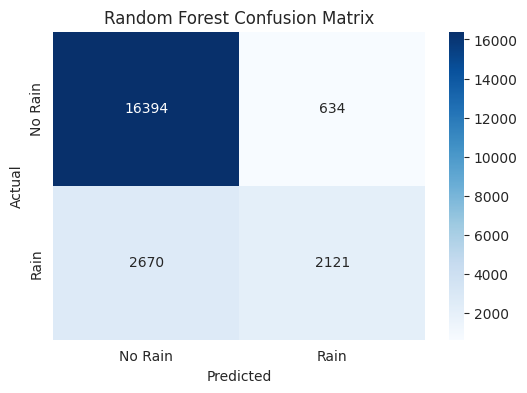

In [102]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Rain','Rain'],
    yticklabels=['No Rain','Rain']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#XGBoost Model

In [103]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

#Evaluation

In [104]:

# Predictions
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

# Accuracy
print("Training Accuracy =", accuracy_score(y_train, y_train_pred) * 100)
print("Testing Accuracy =", accuracy_score(y_test, y_test_pred) * 100)

# Classification Report
print("\n--- Training Classification Report ---")
print(classification_report(y_train, y_train_pred))

print("\n--- Testing Classification Report ---")
print(classification_report(y_test, y_test_pred))

Training Accuracy = 86.70130227259335
Testing Accuracy = 85.87469636555296

--- Training Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     79596
           1       0.78      0.54      0.64     22226

    accuracy                           0.87    101822
   macro avg       0.83      0.75      0.78    101822
weighted avg       0.86      0.87      0.86    101822


--- Testing Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.91     17028
           1       0.76      0.52      0.62      4791

    accuracy                           0.86     21819
   macro avg       0.82      0.74      0.76     21819
weighted avg       0.85      0.86      0.85     21819



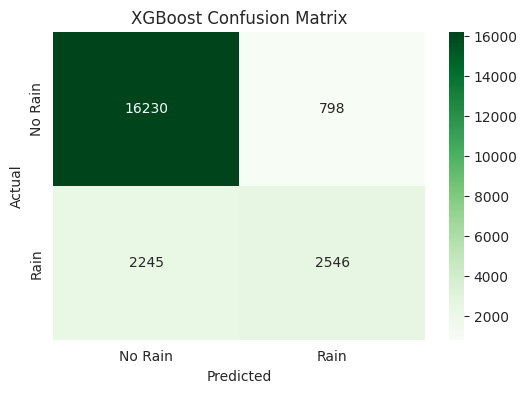

In [105]:
#CONFUSION MATRIX
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Rain','Rain'],
    yticklabels=['No Rain','Rain']
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#Compare Models

In [131]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

trainScores = []
testScores = []

for name, model in models.items():

    print("\nModel:", name)

    model.fit(x_train, y_train)

    train_acc = model.score(x_train, y_train) * 100
    test_acc = model.score(x_test, y_test) * 100

    print("Train:", train_acc)
    print("Test :", test_acc)

    trainScores.append(train_acc)
    testScores.append(test_acc)


Model: RandomForest
Train: 99.99914065722535
Test : 85.24680324487832

Model: XGBoost
Train: 88.84744947064485
Test : 85.71084834318712


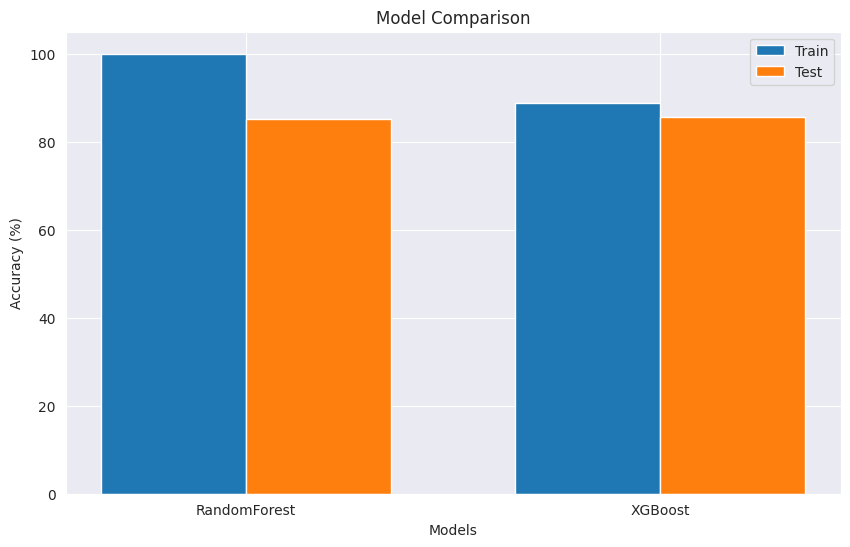

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style('darkgrid')

modelNames = ['RandomForest', 'XGBoost']

bars1 = trainScores
bars2 = testScores

barWidth = 0.35

r1 = np.arange(len(bars1))
r2 = r1 + barWidth

plt.bar(r1, bars1, width=barWidth, label='Train')
plt.bar(r2, bars2, width=barWidth, label='Test')

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')

# ✅ THIS IS THE IMPORTANT LINE
plt.xticks(r1 + barWidth/2, modelNames)

plt.legend()
plt.show()

In [135]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():

    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)

    # Train model
    model.fit(x_train, y_train)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Training Accuracy': round(train_acc*100, 2),
        'Testing Accuracy': round(test_acc*100, 2)
    })

    print(f"\nTraining Accuracy : {train_acc*100:.2f}%")
    print(f"Testing Accuracy  : {test_acc*100:.2f}%")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

# Summary Table
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df)


MODEL: Random Forest

Training Accuracy : 100.00%
Testing Accuracy  : 85.25%

Confusion Matrix:
[[21651  1021]
 [ 3271  3149]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22672
           1       0.76      0.49      0.59      6420

    accuracy                           0.85     29092
   macro avg       0.81      0.72      0.75     29092
weighted avg       0.84      0.85      0.84     29092


MODEL: XGBoost

Training Accuracy : 88.85%
Testing Accuracy  : 85.71%

Confusion Matrix:
[[21482  1190]
 [ 2967  3453]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     22672
           1       0.74      0.54      0.62      6420

    accuracy                           0.86     29092
   macro avg       0.81      0.74      0.77     29092
weighted avg       0.85      0.86      0.85     29092


MODEL COMPARISON SUMMARY
           Model  Train

#ROC-AUC

In [15]:
rf_auc = roc_auc_score(
    y_test,
    rf.predict_proba(X_test)[:,1]
)

xgb_auc = roc_auc_score(
    y_test,
    xgb.predict_proba(X_test)[:,1]
)

print("RF AUC =", rf_auc)

print("XGB AUC =", xgb_auc)

RF AUC = 0.8864234050739274
XGB AUC = 0.8920948930505367


#ROC Curve VIsualization

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#Calculate Probabilities

In [17]:
y_prob = rf.predict_proba(X_test)[:, 1]

#Compute ROC Curve and AUC

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8864234050739274


#Plot ROC Curve

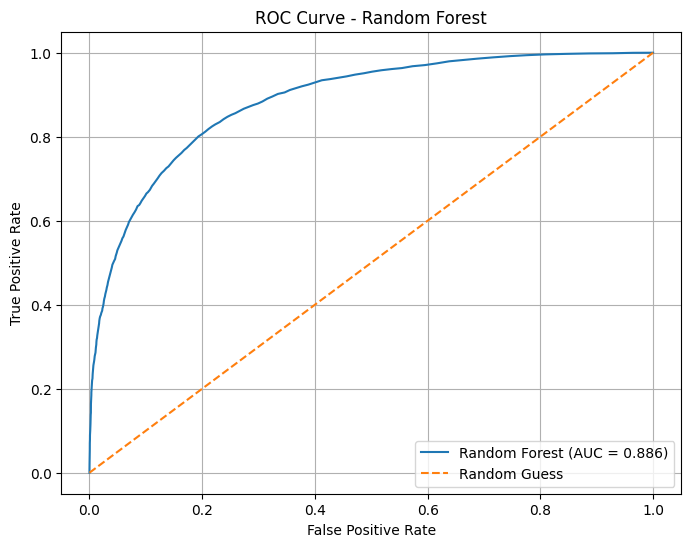

In [19]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {auc_score:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()

#Compare Random Forest and XGBoost on the Same ROC Curve

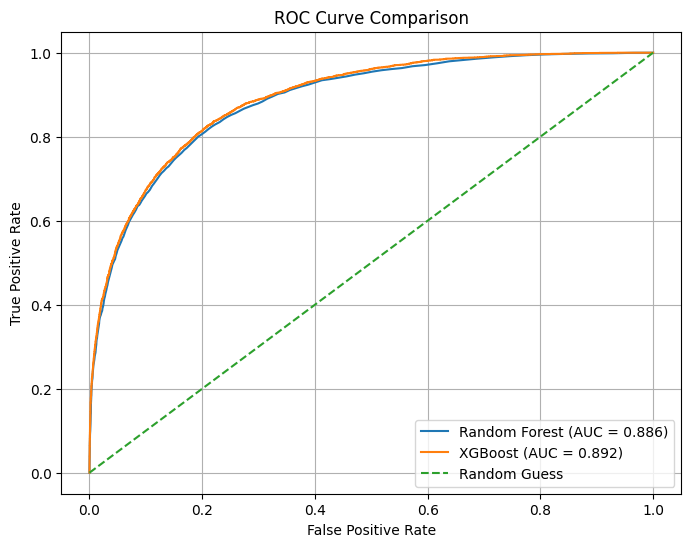

In [20]:
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost (AUC = {xgb_auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()

#MSE finding

In [136]:
from sklearn.metrics import mean_squared_error

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)

    print(f"\n{name}")
    print(f"MSE: {mse:.4f}")


Random Forest
MSE: 0.1475

XGBoost
MSE: 0.1429


#RMSE finding

In [137]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.37800994241967856
